<a href="https://colab.research.google.com/github/anusha-1503/Data-Driven-COVID-19-Detection-Trend-Prediction-Using-Machine-Learning/blob/main/ME_228_Report_1_Module_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Unzip the file to Colab's local /content/ directory
# This usually takes 1-2 minutes for 21k images
!unzip -q "/content/drive/MyDrive/ME 228 Project Datasets/COVID-19_Radiography_Dataset.zip" -d "/content/dataset"

print("✅ Unzip complete! Images are now on Colab's high-speed local drive.")

Mounted at /content/drive
✅ Unzip complete! Images are now on Colab's high-speed local drive.


In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

# This searches your entire MyDrive for one of your metadata files
print("--- Searching for your metadata files ---")
for root, dirs, files in os.walk("/content/drive/MyDrive/"):
    if "COVID.metadata.xlsx" in files:
        print(f"FOUND IT! Your real path is: {root}")
        break
else:
    print("Still can't find 'COVID.metadata.xlsx'. Did you upload it to the 'ME 228 Project Datasets' folder?")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Searching for your metadata files ---
FOUND IT! Your real path is: /content/drive/MyDrive/ME 228 Project Datasets/COVID-19_Radiography_Dataset


In [3]:
import pandas as pd
import os
from sklearn.model_selection import GroupShuffleSplit

# 1. UPDATED PATHS (Based on your successful search)
# This is where the .xlsx files were actually found:
METADATA_DIR = "/content/drive/MyDrive/ME 228 Project Datasets/COVID-19_Radiography_Dataset"

# If you chose the ZIP method, images are here:
# LOCAL_BASE = "/content/dataset/COVID-19_Radiography_Dataset"
# If you are still using Drive directly (slower), images are here:
LOCAL_BASE = METADATA_DIR

files = {
    'COVID': 'COVID.metadata.xlsx',
    'Normal': 'Normal.metadata.xlsx',
    'Lung_Opacity': 'Lung_Opacity.metadata.xlsx',
    'Viral_Pneumonia': 'Viral Pneumonia.metadata.xlsx'
}

dataframes = []

# 2. LOAD & CONSOLIDATE
print("--- Loading Metadata ---")
for label, filename in files.items():
    file_path = os.path.join(METADATA_DIR, filename)

    if os.path.exists(file_path):
        df = pd.read_excel(file_path)
        df['label'] = label

        # Link to the images
        folder_name = label.replace('_', ' ')
        df['image_path'] = df['FILE NAME'].apply(
            lambda x: os.path.join(LOCAL_BASE, folder_name, 'images', f"{x}.png")
        )
        dataframes.append(df)
        print(f" Loaded {filename}")
    else:
        print(f"!! Still missing: {filename}")

# 3. CONCATENATE & SPLIT
if len(dataframes) > 0:
    full_df = pd.concat(dataframes, ignore_index=True)

    # Patient-Level Split (80/10/10)
    full_df['patient_id'] = full_df['FILE NAME'].apply(lambda x: x.split('-')[1])

    gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
    train_idx, temp_idx = next(gss.split(full_df, groups=full_df['patient_id']))

    train_df = full_df.iloc[train_idx].copy()
    temp_df = full_df.iloc[temp_idx].copy()

    gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
    val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['patient_id']))

    val_df, test_df = temp_df.iloc[val_idx], temp_df.iloc[test_idx]

    # print(f"\n🎉 SUCCESS!")
    print(f"\nTotal Rows: {len(full_df)}")
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
else:
    print("\n ERROR: Still no files found. Double check the file names in Drive.")

--- Loading Metadata ---
 Loaded COVID.metadata.xlsx
 Loaded Normal.metadata.xlsx
 Loaded Lung_Opacity.metadata.xlsx
 Loaded Viral Pneumonia.metadata.xlsx

Total Rows: 21165
Train: 16873 | Val: 2118 | Test: 2174


In [5]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. THE ROBUST DATA GENERATOR
# This version filters missing images and prevents "Empty Batch" crashes
class RobustCXRGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, img_size=(224, 224), shuffle=True):
        # Pre-filter: Only keep rows where the image file actually exists
        print(f"Checking file existence for {len(df)} images...")
        self.df = df[df['image_path'].apply(lambda x: os.path.exists(x))].copy()
        print(f"Found {len(self.df)} valid images.")

        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        self.labels_map = {'COVID': 0, 'Normal': 1, 'Lung_Opacity': 2, 'Viral_Pneumonia': 3}
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return len(self.df) // self.batch_size

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        index_range = self.indices[index*self.batch_size : (index+1)*self.batch_size]
        batch = self.df.iloc[index_range]
        X, y = [], []

        for _, row in batch.iterrows():
            img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = self.clahe.apply(img)
                img = cv2.resize(img, self.img_size)
                # Convert to 3-channel for CNN compatibility
                X.append(cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) / 255.0)
                y.append(self.labels_map[row['label']])

        # Safety check: If a batch is empty, grab the next available one
        if len(X) == 0:
            return self.__getitem__((index + 1) % self.__len__())

        return np.array(X), np.array(y)

# 2. INITIALIZE GENERATORS
train_gen = RobustCXRGenerator(train_df, shuffle=True)
val_gen = RobustCXRGenerator(val_df, shuffle=True)
test_gen = RobustCXRGenerator(test_df, shuffle=False)

# 3. BUILD THE BASELINE CNN
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Added dropout to help with the high accuracy/overfitting balance
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. PHASE 1: TRAINING
print("\n--- Starting Phase 1: Training ---")
history = model.fit(train_gen, validation_data=val_gen, epochs=5)

# 5. PHASE 2: EVALUATION & ACCURACY CALCULATION
print("\n--- Starting Phase 2: Final Evaluation ---")

# Predict on Test Set
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get actual labels from test_gen
y_true = []
for i in range(len(test_gen)):
    _, labels = test_gen[i]
    y_true.extend(labels)
y_true = np.array(y_true)

# Final Metrics
final_acc = accuracy_score(y_true, y_pred)
print(f"\nFINAL TEST ACCURACY: {final_acc * 100:.2f}%")

target_names = ['COVID', 'Normal', 'Lung_Opacity', 'Viral_Pneumonia']
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 6. VISUALIZE CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Robust Baseline CNN')
plt.show()

Checking file existence for 16873 images...
Found 3912 valid images.
Checking file existence for 2118 images...
Found 505 valid images.
Checking file existence for 2174 images...
Found 544 valid images.

--- Starting Phase 1: Training ---
Epoch 1/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 420s 3s/step - accuracy: 0.8940 - loss: 0.4384 - val_accuracy: 0.9563 - val_loss: 0.1363
Epoch 2/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 416s 3s/step - accuracy: 0.9654 - loss: 0.1055 - val_accuracy: 0.9812 - val_loss: 0.0523
Epoch 3/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 415s 3s/step - accuracy: 0.9675 - loss: 0.0974 - val_accuracy: 0.9812 - val_loss: 0.0586
Epoch 4/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.9703 - loss: 0.0866 - val_accuracy: 0.9812 - val_loss: 0.0660
Epoch 5/5
122/122 ━━━━━━━━━━━━━━━━━━━━ 418s 3s/step - accuracy: 0.9752 - loss: 0.0788 - val_accuracy: 0.9792 - val_loss: 0.0764

--- Starting Phase 2: Final Evaluation ---
17/17 ━━━━━━━━━━━━━━━━━━━━ 195s 12s/step

FINAL TEST ACCURACY: 99.08%

Classi

ValueError: Number of classes, 2, does not match size of target_names, 4. Try specifying the labels parameter

Classes found in this sub-sample: ['COVID', 'Viral_Pneumonia']

Classification Report (Sub-sample):
                 precision    recall  f1-score   support

          COVID       0.99      1.00      0.99       400
Viral_Pneumonia       1.00      0.97      0.98       144

       accuracy                           0.99       544
      macro avg       0.99      0.98      0.99       544
   weighted avg       0.99      0.99      0.99       544



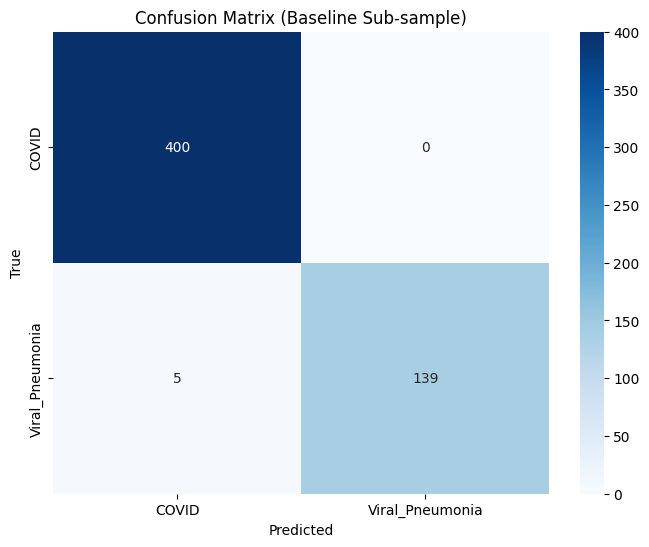

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Figure out which classes were actually present in this run
unique_classes = np.unique(np.concatenate([y_true, y_pred]))
# Map those numbers back to the names
actual_labels = ['COVID', 'Normal', 'Lung_Opacity', 'Viral_Pneumonia']
present_names = [actual_labels[i] for i in unique_classes]

print(f"Classes found in this sub-sample: {present_names}")

# 2. Print the report for ONLY those classes
print("\nClassification Report (Sub-sample):")
print(classification_report(y_true, y_pred, target_names=present_names))

# 3. Plot the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Baseline Sub-sample)')
plt.show()